## **About** **Dataset**


### **Context**
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective is to predict based on diagnostic measurements whether a patient has diabetes.

### **Content**
Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

##### **Pregnancies**: Number of times pregnant
##### **Glucose**:Plasma glucose concentration a 2 hours in an oral glucose tolerance test
##### BloodPressure: Diastolic blood pressure (mm Hg)
##### **SkinThickness**: Triceps skin fold thickness (mm)
##### **Insulin**: 2-Hour serum insulin (mu U/ml)
##### **BMI**: Body mass index (weight in kg/(height in m)^2)
##### **DiabetesPedigreeFunction**: Diabetes pedigree function
##### **Age**: Age (years)
##### **Outcome**: Class variable (0 or 1)
## **Info**
#### Number of Instances: 768
#### Number of Attributes: 8 plus class
#### Class variable (0 or 1)
#### Missing Attribute Values: Yes


In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import gradio as gr
from sklearn.preprocessing import scale, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, f1_score, roc_auc_score, roc_curve, classification_report, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from category_encoders import CountEncoder

In [109]:
df = pd.read_csv('/content/diabetes.csv')

# Phase #1

## Explore Data

In [110]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [112]:
df.isna().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## Analysis

In [115]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


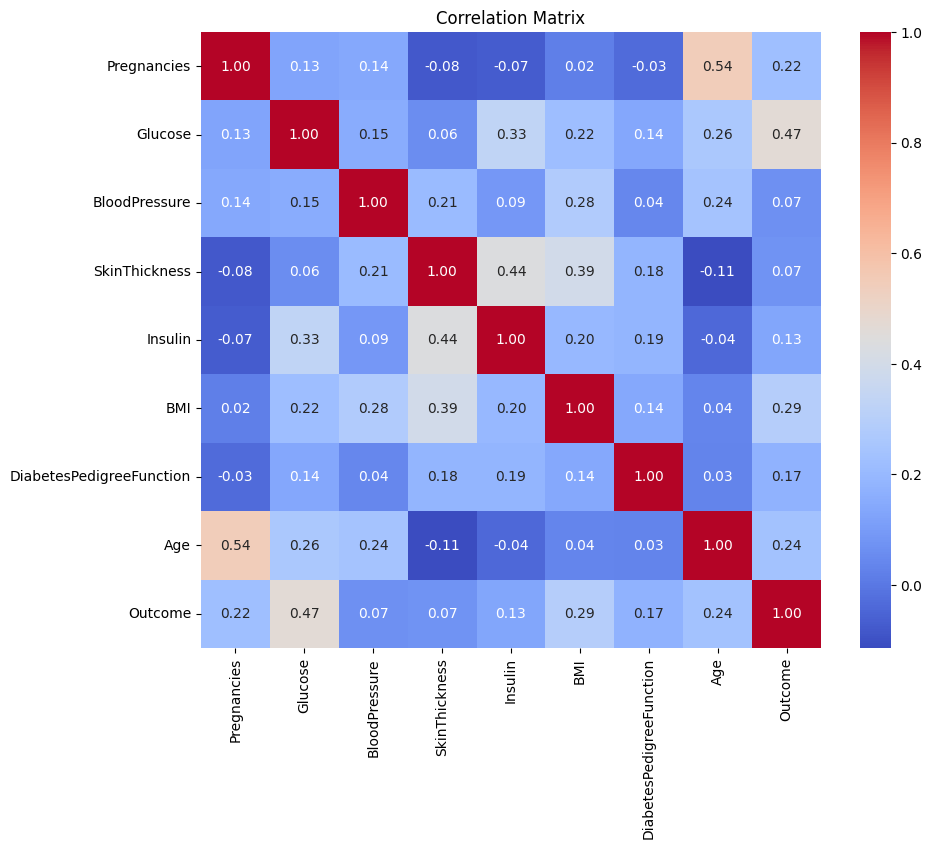

In [116]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [117]:
for col in df.columns:
    if str(col) !='Outcome':
        print(f"Mean of {col} grouped by Outcome:\n")
        print(df.groupby("Outcome").agg({col: 'mean'}))
        print("\n" + "="*50 + "\n")

Mean of Pregnancies grouped by Outcome:

         Pregnancies
Outcome             
0           3.298000
1           4.865672


Mean of Glucose grouped by Outcome:

            Glucose
Outcome            
0        109.980000
1        141.257463


Mean of BloodPressure grouped by Outcome:

         BloodPressure
Outcome               
0            68.184000
1            70.824627


Mean of SkinThickness grouped by Outcome:

         SkinThickness
Outcome               
0            19.664000
1            22.164179


Mean of Insulin grouped by Outcome:

            Insulin
Outcome            
0         68.792000
1        100.335821


Mean of BMI grouped by Outcome:

               BMI
Outcome           
0        30.304200
1        35.142537


Mean of DiabetesPedigreeFunction grouped by Outcome:

         DiabetesPedigreeFunction
Outcome                          
0                        0.429734
1                        0.550500


Mean of Age grouped by Outcome:

               Age
Outcom

## Visualization

### Boxplots of all columns

In [118]:
fig = go.Figure()
for col in df.columns:
    fig.add_trace(go.Box(y=df[col], name=col))

fig.update_layout(
    title="Boxplots of all columns",
    xaxis_title= "Column",
    yaxis_title= "Value"
)

fig.show()

### The distribution of every column  

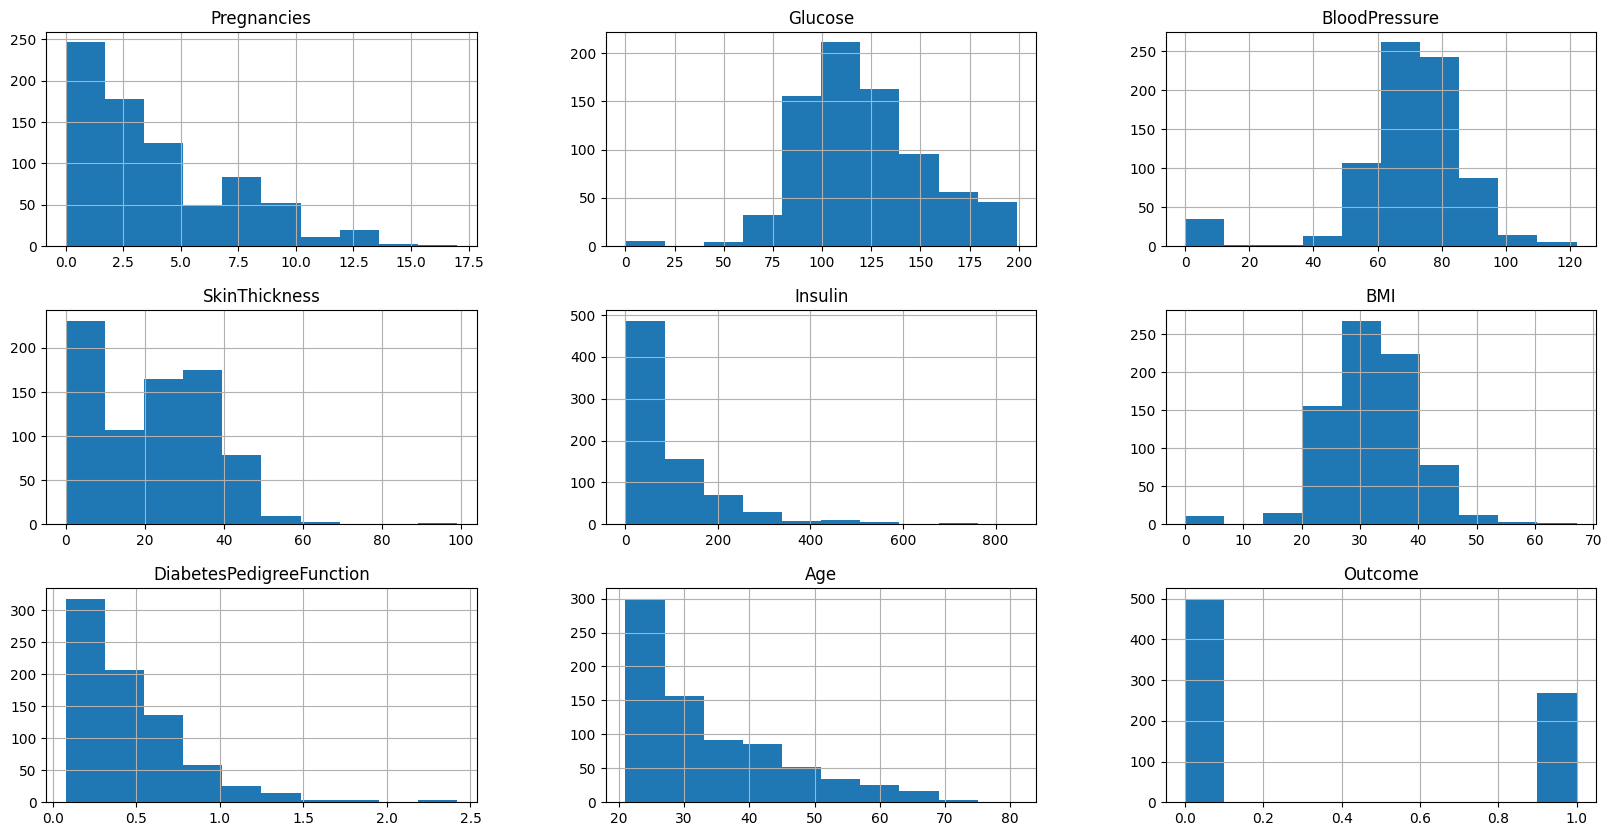

In [119]:
df.hist(figsize=(20,10))
plt.show()

 ### **How many patients have diabetes versus those who don’t?**

In [120]:
outcome_counts = df['Outcome'].value_counts().reset_index()
outcome_counts.columns = ['Outcome', 'Count']
fig = px.bar(outcome_counts, x='Outcome', y='Count', title='Outcome Distribution')
fig.show()

### **What’s the relationship between glucose levels and the outcome?**

/tmp/ipython-input-313798463.py:1: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipython-input-313798463.py:2: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




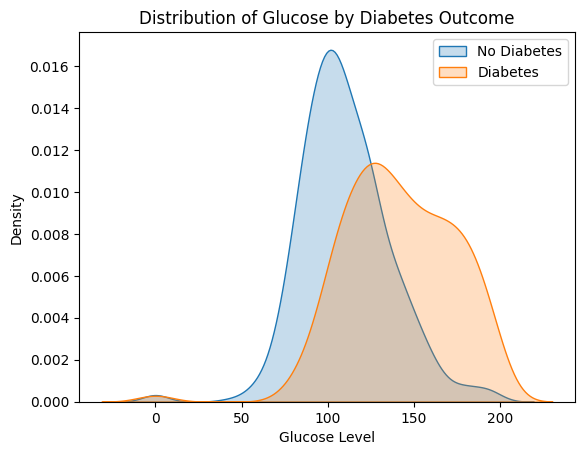

In [121]:
sns.kdeplot(data=df[df["Outcome"]==0]["Glucose"], label="No Diabetes", shade=True)
sns.kdeplot(data=df[df["Outcome"]==1]["Glucose"], label="Diabetes", shade=True)
plt.title("Distribution of Glucose by Diabetes Outcome")
plt.xlabel("Glucose Level")
plt.legend()
plt.show()


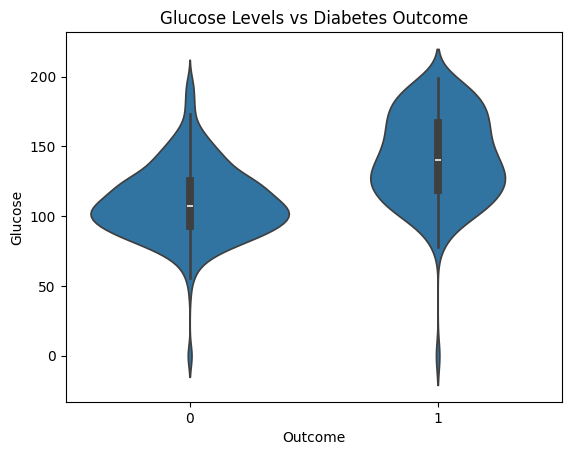

In [122]:
sns.violinplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose Levels vs Diabetes Outcome")
plt.show()


**patients with diabetes (Outcome = 1) have significantly higher glucose levels compared to non-diabetic patients. The median glucose for the diabetic group is much higher, highlighting glucose as the strongest predictor of diabetes.**

### **Does BMI play a significant role?**

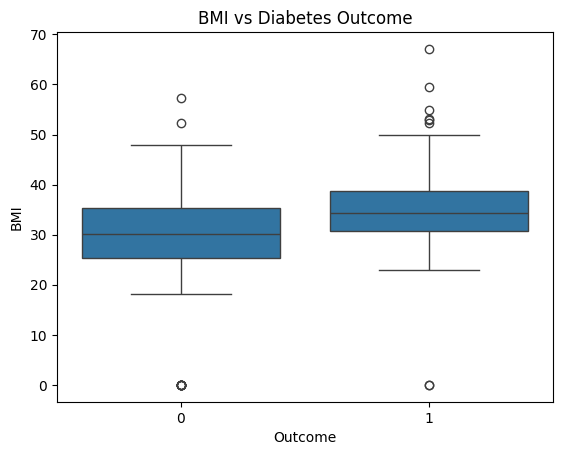

In [123]:
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI vs Diabetes Outcome")
plt.show()

**diabetic patients (Outcome = 1) tend to have higher BMI compared to non-diabetic patients (Outcome = 0). The higher median BMI in the diabetic group suggests BMI is an important risk factor**

In [124]:
lvl3 = df[df['BMI'] > 43]
outcome_counts = lvl3['Outcome'].value_counts().reset_index()
outcome_counts.columns = ['Outcome', 'Count']
fig = px.bar(outcome_counts, x='Outcome', y='Count', title='Outcome Distribution for level 3 Obesity')
fig.show()

**Obesity** has a direct and significant effect on the development of Type 2 diabetes, primarily through a mechanism called insulin resistance.

### Plot #1

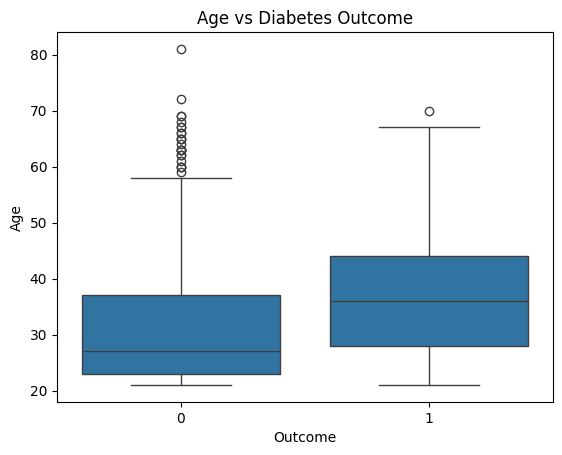

In [125]:
sns.boxplot(x="Outcome", y="Age", data=df)
plt.title("Age vs Diabetes Outcome")
plt.show()

**diabetic patients are generally older than non-diabetic patients. The age distribution for the diabetic group is shifted toward higher values, indicating that age is a significant factor in the likelihood of developing diabetes**

### Plot #2

In [126]:
fig = px.scatter(df, x=df.index, y='Insulin', color='Outcome', title='Insulin Distribution by Outcome')
fig.show()

As the plot cant show the insulin effect but the insulin really effects the diabetes development by the insulin resistance


### Plot #3

In [127]:
agecount = df.groupby(['Age', 'Outcome']).size().reset_index(name='Count')

fig = px.bar(agecount, x='Age', y='Count', color='Outcome',
             title='Outcome Count by Age')
fig.show()

Age doesnot effect the out come too much

# Phase #2

## Data preparation

#### Null fixing as i could

In [140]:
missing_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[missing_columns] = df[missing_columns].replace(0, np.nan)

In [143]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [142]:
df.fillna(df.median(), inplace=True)

#### Outliers

In [128]:
def outlier_percent(df):
    outlier_info = {}

    for col in df.select_dtypes(include='number').columns:
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 5:
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        percent = 100 * len(outliers) / len(df)

        outlier_info[col] = round(percent, 2)

    return pd.DataFrame.from_dict(outlier_info, orient='index', columns=['Outlier %'])

outlier_percent(df)

,Outlier %
Pregnancies,0.52
Glucose,0.65
BloodPressure,5.86
SkinThickness,0.13
Insulin,4.43
BMI,2.47
DiabetesPedigreeFunction,3.78
Age,1.17


In [129]:
def remove_outliers_iqr(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR


    filtered_df = df[
        df[column].isna() |
        ((df[column] >= lower_bound) & (df[column] <= upper_bound))
    ]

    return filtered_df

In [130]:
df = remove_outliers_iqr(df, 'BloodPressure')
df = remove_outliers_iqr(df, 'Insulin')
df = remove_outliers_iqr(df, 'DiabetesPedigreeFunction')

In [131]:
outlier_percent(df)

,Outlier %
Pregnancies,0.60
Glucose,1.95
BloodPressure,0.60
SkinThickness,0.15
Insulin,1.05
BMI,1.35
DiabetesPedigreeFunction,1.80
Age,1.20


In [132]:
x = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].copy()

### Data Scaling

In [133]:
StandardScaler = StandardScaler()
x_scaled = StandardScaler.fit_transform(x)

### Data splitting

In [134]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Phase #3

In [135]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x_scaled, y)


In [144]:
models = {
    "Logistic Regression": GridSearchCV(
        LogisticRegression(max_iter=500),
        {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]},
        cv=5
    ),
    "SVC": GridSearchCV(
        SVC(probability=True, random_state=42),
        {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1], "kernel": ["rbf"]},
        cv=5
    ),
    "Random Forest": GridSearchCV(
        RandomForestClassifier(random_state=42),
        {"n_estimators": [200, 300], "max_depth": [10, 15, None],
         "min_samples_split": [2, 4], "min_samples_leaf": [1, 2],
         "max_features": ["sqrt", "log2"]},
        cv=5
    ),
    "Gradient Boosting": GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        {"n_estimators": [300, 500], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]},
        cv=5
    )
}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:,1]

    print(f"\n{name}")
    print("Best Params:", model.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))


Logistic Regression
Best Params: {'C': 10, 'solver': 'liblinear'}
Accuracy: 0.7910447761194029
F1 Score: 0.631578947368421
ROC-AUC: 0.8571777940816826
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        87
           1       0.83      0.51      0.63        47

    accuracy                           0.79       134
   macro avg       0.80      0.73      0.74       134
weighted avg       0.80      0.79      0.78       134


SVC
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.7835820895522388
F1 Score: 0.6027397260273972
ROC-AUC: 0.8019075568598678
              precision    recall  f1-score   support

           0       0.77      0.95      0.85        87
           1       0.85      0.47      0.60        47

    accuracy                           0.78       134
   macro avg       0.81      0.71      0.73       134
weighted avg       0.80      0.78      0.76       134


Random Forest
Best Params: {'max_depth': 10, 

## So the Top three was SVC  RF LR

In [145]:
#SMote
sm_x_train, sm_x_test, sm_y_train, sm_y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [147]:
x_sm_scaled = StandardScaler.fit_transform(sm_x_train)


In [148]:
param_lr = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]}
model_lr = GridSearchCV(LogisticRegression(max_iter=500, random_state=42),
                        param_lr, scoring="accuracy", cv=5)

param_svc = {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1], "kernel": ["rbf"]}
model_svc = GridSearchCV(SVC(probability=True, random_state=42),
                         param_svc, scoring="accuracy", cv=5)

param_rf = {"n_estimators": [200, 300],
            "max_depth": [10, 15, None],
            "min_samples_split": [2, 4],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt", "log2"]}
model_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                        param_rf, scoring="accuracy", cv=5)

best_lr = tuning(model_lr, "Logistic Regression", sm_x_train, sm_y_train, sm_x_test, sm_y_test)
best_svc = tuning(model_svc, "SVM", sm_x_train, sm_y_train, sm_x_test, sm_y_test)
best_rf = tuning(model_rf, "Random Forest", sm_x_train, sm_y_train, sm_x_test, sm_y_test)

print("Logistic Regression Best CV Accuracy:", model_lr.best_score_)
print("SVM Best CV Accuracy:", model_svc.best_score_)
print("Random Forest Best CV Accuracy:", model_rf.best_score_)


=== Logistic Regression Results ===
Accuracy: 0.7514
Recall: 0.7978
F1: 0.7594
Auc: 0.7968

=== SVM Results ===
Accuracy: 0.8066
Recall: 0.7978
F1: 0.8023
Auc: 0.8392

=== Random Forest Results ===
Accuracy: 0.7901
Recall: 0.8315
F1: 0.7957
Auc: 0.8655
Logistic Regression Best CV Accuracy: 0.750383141762452
SVM Best CV Accuracy: 0.7989559386973181
Random Forest Best CV Accuracy: 0.8335919540229885


## Best Model IS RF ✅

In [151]:
model_rf.fit(x_sm_scaled, sm_y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 4],
                         'n_estimators': [200, 300]},
             scoring='accuracy')

# Phase #4

In [163]:

scaler = StandardScaler()
x_sm_scaled = scaler.fit_transform(sm_x_train)

model_rf.fit(x_sm_scaled, sm_y_train)


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 4],
                         'n_estimators': [200, 300]},
             scoring='accuracy')

In [165]:
import numpy as np
import gradio as gr

def predict_diabetes(pregnancies, glucose, bloodpressure, skinthickness, insulin, bmi, dpf, age):
    data = np.array([[pregnancies, glucose, bloodpressure, skinthickness, insulin, bmi, dpf, age]])
    data_scaled = scaler.transform(data)   # ✅ use the fitted scaler
    pred = model_rf.predict(data_scaled)[0]
    proba = model_rf.predict_proba(data_scaled)[0][1]  # probability of diabetic
    return f"🩺 Diabetic (Confidence: {proba*100:.2f}%)" if pred == 1 else f"✅ Non-Diabetic (Confidence: {(1-proba)*100:.2f}%)"


# interface
demo = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose"),
        gr.Number(label="BloodPressure"),
        gr.Number(label="SkinThickness"),
        gr.Number(label="Insulin"),
        gr.Number(label="BMI"),
        gr.Number(label="DiabetesPedigreeFunction"),
        gr.Number(label="Age"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🩺 Diabetes Prediction Engine",
    description="Enter patient medical data to check if they are likely Diabetic or Non-Diabetic"
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://187f6eeaf59e5c6c9e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
